# Differentiation

**Source:** https://labs.acme.byu.edu/Volume1/Differentiation/Differentiation.html

This lab explores three derivative computation approaches: symbolic differentiation (SymPy), numerical differentiation (finite difference quotients), and their convergence properties.

In [1]:
import numpy as np
import sympy as sy

import matplotlib.pyplot as plt

## 1. Symbolic Differentiation

SymPy computes exact derivatives as expressions.

In [2]:
x = sy.symbols('x')
f = sy.sin(x)**2
print(sy.diff(f, x))          # 2*sin(x)*cos(x)

print(sy.diff(f, x, 2))       # second derivative

2*sin(x)*cos(x)
2*(-sin(x)**2 + cos(x)**2)


## 2. Numerical Differentiation — Finite Difference Formulas

| Formula | Expression | Order |
|---------|-----------|-------|
| Forward  O(h)  | `[f(x+h) - f(x)] / h` | 1 |
| Backward O(h)  | `[f(x) - f(x-h)] / h` | 1 |
| Centered O(h²) | `[f(x+h) - f(x-h)] / (2h)` | 2 |
| Forward  O(h²) | `[-3f(x) + 4f(x+h) - f(x+2h)] / (2h)` | 2 |
| Backward O(h²) | `[3f(x) - 4f(x-h) + f(x-2h)] / (2h)` | 2 |
| Centered O(h⁴) | `[-f(x+2h) + 8f(x+h) - 8f(x-h) + f(x-2h)] / (12h)` | 4 |

---

## Problem 1: Symbolic Derivative of f(x) = (sin(x)+1)^sin(cos(x))

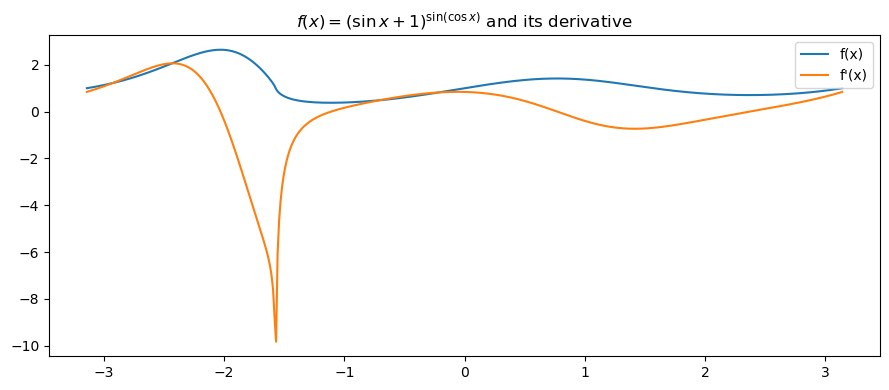

In [3]:
def prob1():
    x = sy.symbols('x')
    f = (sy.sin(x) + 1) ** sy.sin(sy.cos(x))
    df = sy.diff(f, x)
    f_fn  = sy.lambdify(x, f,  'numpy')
    df_fn = sy.lambdify(x, df, 'numpy')
    return f_fn, df_fn

f_fn, df_fn = prob1()

x_vals = np.linspace(-np.pi, np.pi, 500)

plt.figure(figsize=(9, 4))
plt.plot(x_vals, f_fn(x_vals),  label='f(x)')
plt.plot(x_vals, df_fn(x_vals), label="f'(x)")
plt.legend()
plt.title(r'$f(x) = (\sin x + 1)^{\sin(\cos x)}$ and its derivative')
plt.tight_layout()
plt.show()

## Problem 2: Finite Difference Functions

Implement all six finite difference formulas.

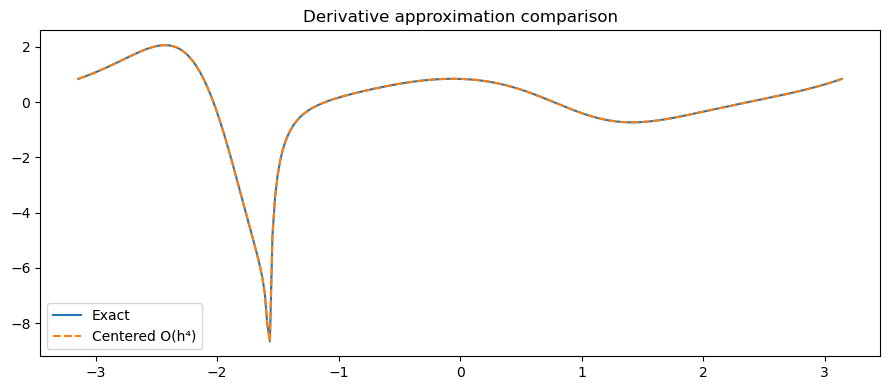

In [4]:
def forward_o1(f, pts, h=1e-5):
    """Forward difference, O(h) accuracy."""
    return (f(pts + h) - f(pts)) / h

def backward_o1(f, pts, h=1e-5):
    """Backward difference, O(h) accuracy."""
    return (f(pts) - f(pts - h)) / h

def centered_o2(f, pts, h=1e-5):
    """Centered difference, O(h²) accuracy."""
    return (f(pts + h) - f(pts - h)) / (2*h)
    

def forward_o2(f, pts, h=1e-5):
    """Forward difference, O(h²) accuracy."""
    return (-3*f(pts) + 4*f(pts+h) - f(pts+2*h)) / (2*h)

def backward_o2(f, pts, h=1e-5):
    """Backward difference, O(h²) accuracy."""
    return (3*f(pts) - 4*f(pts-h) + f(pts-2*h)) / (2*h)

def centered_o4(f, pts, h=1e-5):
    """Centered difference, O(h⁴) accuracy."""
    return (-f(pts+2*h) + 8*f(pts+h) - 8*f(pts-h) + f(pts-2*h)) / (12*h)


# Test against symbolic derivative
x_vals = np.linspace(-np.pi, np.pi, 300)
exact   = df_fn(x_vals)
approx  = centered_o4(f_fn, x_vals)

plt.figure(figsize=(9, 4))
plt.plot(x_vals, exact,  label='Exact')
plt.plot(x_vals, approx, '--', label='Centered O(h⁴)')
plt.legend()
plt.title('Derivative approximation comparison')
plt.tight_layout()
plt.show()

## Problem 3: Convergence Analysis

Plot absolute error vs. h on a log-log scale for all six methods at x₀ = 1.

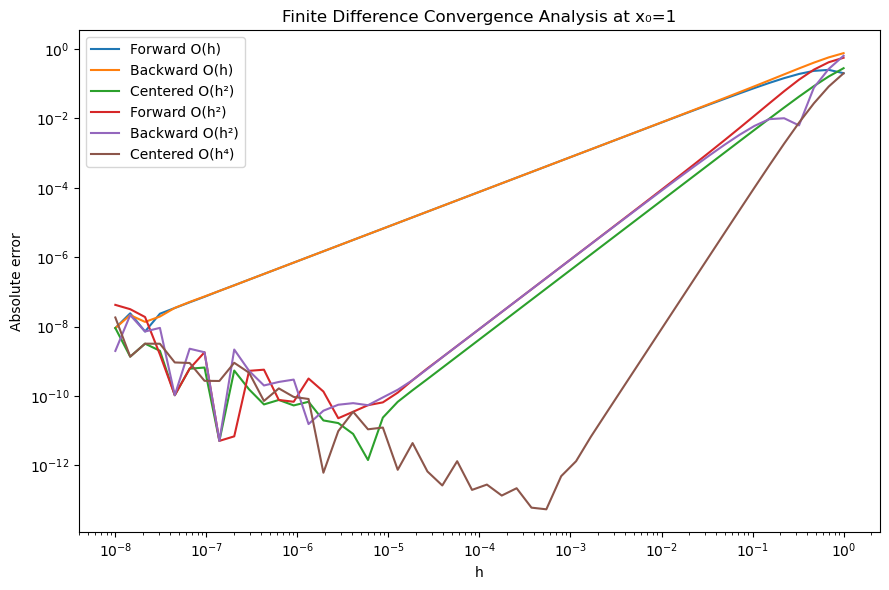

In [5]:
x0 = 1.0
exact_deriv = df_fn(x0)
h_values = np.logspace(-8, 0, 50)

methods = [
    ('Forward O(h)',    forward_o1),
    ('Backward O(h)',   backward_o1),
    ('Centered O(h²)',  centered_o2),
    ('Forward O(h²)',   forward_o2),
    ('Backward O(h²)',  backward_o2),
    ('Centered O(h⁴)',  centered_o4),
]

plt.figure(figsize=(9, 6))
for name, method in methods:
    errors = [abs(method(f_fn, np.array([x0]), h=h)[0] - exact_deriv) for h in h_values]
    plt.loglog(h_values, errors, label=name)


plt.xlabel('h')
plt.ylabel('Absolute error')
plt.legend()
plt.title('Finite Difference Convergence Analysis at x₀=1')
plt.tight_layout()
plt.show()

## Problem 4: Multivariable Finite Differences

Extend centered differences to partial derivatives of f: ℝⁿ → ℝ.

In [6]:
def partial_derivative(f, x0, j, h=1e-5):
    """Approximate ∂f/∂xⱼ at point x0 using centered O(h²) difference."""
    x0 = np.array(x0, dtype=float)
    e_j = np.zeros_like(x0)
    e_j[j] = 1.0
    return (f(x0 + h*e_j) - f(x0 - h*e_j)) / (2*h)

def gradient(f, x0, h=1e-5):
    """Approximate the full gradient ∇f at x0."""
    x0 = np.array(x0, dtype=float)
    return np.array([partial_derivative(f, x0, j, h) for j in range(len(x0))])

# Test: f(x,y,z) = x²y + y³z, gradient at (1,2,3)
g = lambda v: v[0]**2 * v[1] + v[1]**3 * v[2]
x0 = np.array([1., 2., 3.])
numerical_grad = gradient(g, x0)
# Exact: [2xy, x²+3y²z, y³] = [4, 1+36, 8] = [4, 37, 8]
exact_grad = np.array([2*1*2, 1**2 + 3*4*3, 2**3])

print("Numerical:", numerical_grad)
print("Exact:    ", exact_grad)
print("Max error:", np.max(np.abs(numerical_grad - exact_grad)))

Numerical: [ 4. 37.  8.]
Exact:     [ 4 37  8]
Max error: 5.532569957722444e-10


## Problem 5: Jacobian Construction

In [7]:
def jacobian(F, x0, h=1e-5):
    """Approximate Jacobian of F: ℝⁿ → ℝᵐ at x0.
    
    Returns an (m×n) matrix where J[i,j] = ∂Fᵢ/∂xⱼ.
    """
    x0 = np.array(x0, dtype=float)
    n = len(x0)
    m = len(F(x0))
    J = np.zeros((m, n))
    for j in range(n):
        e_j = np.zeros(n)
        e_j[j] = 1.0
        J[:, j] = (F(x0 + h*e_j) - F(x0 - h*e_j)) / (2*h)
    return J

# Test: F(x,y) = [x²+y, x*sin(y)]
F = lambda v: np.array([v[0]**2 + v[1], v[0]*np.sin(v[1])])
x0 = np.array([1., np.pi/4])
J_num = jacobian(F, x0)
# Exact: [[2x, 1], [sin(y), x*cos(y)]]
J_exact = np.array([[2*x0[0], 1],
                    
                     [np.sin(x0[1]), x0[0]*np.cos(x0[1])]])
print("Numerical Jacobian:\n", J_num)
print("Exact Jacobian:\n",     J_exact)
print("Max error:", np.max(np.abs(J_num - J_exact)))

Numerical Jacobian:
 [[2.         1.        ]
 [0.70710678 0.70710678]]
Exact Jacobian:
 [[2.         1.        ]
 [0.70710678 0.70710678]]
Max error: 1.3963719069920444e-11
